In [1]:
from baja.sample_data import load_cubs_traj_data
import numpy as np
import matplotlib.pyplot as plt
import rerun as rr


In [2]:
df = load_cubs_traj_data("0.1s")[:200]
# df = pd.read_parquet("../data/cub_sample_traj.parquet")
seq_len = len(df)

In [3]:
ts = df.index.to_numpy().astype(np.datetime64)
target_pos = df[["x", "y", "z"]].to_numpy()
rng = np.random.default_rng(12345)
n_points = 50
offsets = rng.normal(scale=0.5, size=(n_points, seq_len, 3))
radii = rng.uniform(0.1, 0.3, size=[seq_len, n_points])
cloud = target_pos + offsets
B, T, D = cloud.shape

sensor_pos = np.array(
    [
        [20, 5, 10],
        [20, -5, 10],
        [-5, 5, 10],
        [-5, -5, 10],
    ]
)
# sensor_pos = np.expand_dims(sensor_pos, 1)
dist_meas = np.linalg.norm((target_pos - sensor_pos[:, None, :]), axis=-1)
bearing_meas = (target_pos - sensor_pos[:, None, :]) / dist_meas[..., None]

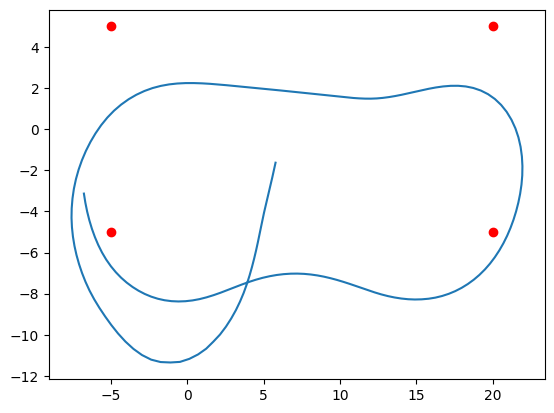

In [4]:
fig = plt.figure()
ax = fig.add_subplot()
ax.plot(df.x, df.y)
ax.scatter(sensor_pos[..., 0], sensor_pos[..., 1], c="r")

In [5]:
# rr.init("traj_vis")
# # rr.connect_grpc()
# time = rr.TimeColumn("time", timestamp=ts)
# rr.log(
#     "sensors/location",
#     rr.Points3D(positions=sensor_pos, radii=[0.2] * 4),
#     static=True,
#     strict=True,
# )
# rr.log(
#     "traj/line",
#     rr.LineStrips3D(strips=target_pos, radii=[0.05], colors=[0x43AAFFC3]),
#     static=True,
#     strict=True,
# )

# rr.send_columns(
#     "traj/true",
#     indexes=[time],
#     columns=[
#         *rr.Points3D.columns(
#             positions=target_pos, radii=[0.5] * seq_len, colors=[(255, 0, 0)] * seq_len
#         )
#     ],
# )

# rr.send_columns(
#     "sensors/bearing",
#     indexes=[time],
#     columns=[
#         *rr.Arrows3D.columns(
#             vectors=bearing_meas.transpose(1, 0, 2).reshape(-1, 3) * 2,
#             origins=np.tile(sensor_pos, (1, seq_len, 1))
#             .transpose(1, 0, 2)
#             .reshape(-1, 3),
#         ).partition([4] * seq_len),
#     ],
# )
# rr.send_columns(
#     "sensors/range",
#     indexes=[time],
#     columns=[
#         *rr.Points3D.columns(
#             positions=np.tile(sensor_pos, (1, seq_len, 1))
#             .transpose(1, 0, 2)
#             .reshape(-1, 3),
#             radii=dist_meas.transpose().reshape(-1),
#             colors=[0x43ff644d] * 4*seq_len,
#         ).partition([4] * seq_len)
#     ],
# )

# # rr.send_columns(
# #     "traj/cloud",
# #     indexes=[rr.TimeColumn("time", timestamp=ts)],
# #     columns=[
# #         *rr.Points3D.columns(
# #             positions=cloud.transpose(1, 0, 2).reshape((-1, 3)),
# #             radii=radii.reshape((-1)),
# #         ).partition([n_points] * seq_len),
# #     ],
# # )

# rr.notebook_show()

In [6]:
dist_meas.shape, sensor_pos.shape

((4, 200), (4, 3))

In [7]:
from baja import pf, ekf, ukf, pff
import jax.numpy as jnp
import jax.random as jr


def dynamics_fn(states):
    dt = 0.1  # because we resampled every 0.1s -> 10hz,
    A = np.block(
        [[np.eye(3), dt * np.eye(3)], [np.zeros((3, 3)), np.eye(3)]]
    )  # simple LTI process model
    return (A @ states.T).T


def dist_meas_fn(states):
    pos = states[:3]
    dist_meas = jnp.linalg.norm(pos - sensor_pos, axis=-1)
    return dist_meas


def bearing_meas_fn(states):
    """
    bearing vector, not angle
    """

    pos = states[:3]
    dist_meas = jnp.linalg.norm(pos - sensor_pos, axis=-1)
    bearing = (pos - sensor_pos) / dist_meas[:, None]
    return bearing.flatten()


key = jr.key(111)
n_meas = dist_meas.shape[0]
n_particles = 1000
init_state = np.hstack(
    [
        rng.normal(target_pos[0], size=(n_particles, 3)),
        rng.uniform(-1, 1, (n_particles, 3)),
    ]
)

particles = pf.ParticleState(init_state, np.ones(n_particles), key)
Q = np.diag([1e-1, 1e-1, 1e-1, 0.5, 0.5, 0.5])
R = np.eye(n_meas) * 0.1
filter = pf.ParticleFilter(
    f=dynamics_fn,
    # h=bearing_meas_fn,
    h=dist_meas_fn,
    num_particles=n_particles,
    Q=Q,
    R=R,
)

n_particles = 500
init_state = np.hstack(
    [
        rng.normal(target_pos[0], size=(n_particles, 3)),
        rng.uniform(-1, 1, (n_particles, 3)),
    ]
)
particles2 = pff.ParticleState(init_state, np.ones(n_particles) / n_particles, key)
filter2 = pff.EDHFilter(
    f=dynamics_fn,
    h=dist_meas_fn,
    num_particles=n_particles,
    Q=Q,
    R=R,
)

particles3 = pff.ParticleState(init_state, np.ones(n_particles) / n_particles, key)
filter3 = pff.IEDHFilter(
    f=dynamics_fn,
    h=dist_meas_fn,
    num_particles=n_particles,
    Q=Q,
    R=R,
)

init_state = np.hstack([rng.normal(target_pos[0], size=(3,)), rng.uniform(-1, 1, (3,))])
ekf_state = ekf.GaussianState(mean=init_state, cov=Q)
filter4 = ekf.ExtendedKalmanFilter(
    f=dynamics_fn,
    h=dist_meas_fn,
    Q=Q,
    R=R,
)

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


In [8]:
rr.init("traj_vis")
particle_hist = []
particle_hist.append(particles)

particle2_hist = []
particle2_hist.append(particles2)

particle3_hist = []
particle3_hist.append(particles3)

ekf_hist = []
ekf_hist.append(ekf_state)

rr.log(
    "sensors/location",
    rr.Points3D(positions=sensor_pos, radii=[0.2] * sensor_pos.shape[0]),
    static=True,
    strict=True,
)
rr.log(
    "traj/line",
    rr.LineStrips3D(strips=target_pos, radii=[0.05], colors=[0x43AAFFC3]),
    static=True,
    strict=True,
)

rr.log("traj/cloud_bpf", rr.Points3D(positions=particles.particles[:, :3]))
rr.log("traj/cloud_edh", rr.Points3D(positions=particles2.particles[:, :3]))
rr.log("traj/cloud_iedh", rr.Points3D(positions=particles3.particles[:, :3]))
rr.log(
    "traj/ekf",
    rr.Points3D(
        positions=ekf_state.mean[:3],
        radii=[0.2],
        colors=[(0, 0, 255)],
    ),
)

for i in range(seq_len):
    key, sub_key = jr.split(key)
    
    # we probably need highly non-linear measurement model or non-gaussian distribution to demonstrate pfpf is better than EKF
    dist_noisy = dist_meas[..., i] + jr.uniform(key=sub_key, shape=(n_meas,), minval=-1, maxval=1) * 0.1 

    particles = filter.run_step(particles, dist_noisy)
    particle_hist.append(particles)

    particles2 = filter2.run_step(particles2, dist_noisy)
    particle2_hist.append(particles2)

    particles3 = filter3.run_step(particles3, dist_noisy)
    particle3_hist.append(particles3)

    ekf_state_pred = filter4.predict(ekf_state)
    ekf_state = filter4.update(ekf_state_pred, dist_noisy)
    ekf_hist.append(ekf_state)

    rr.log("traj/cloud_bpf", rr.Points3D(positions=particles.particles[:, :3]))
    rr.log("traj/cloud_edh", rr.Points3D(positions=particles2.particles[:, :3]))
    rr.log("traj/cloud_iedh", rr.Points3D(positions=particles3.particles[:, :3], radii=particles3.weights*0.5))
    rr.log("traj/ekf", rr.Points3D(positions=ekf_state.mean[:3]))
    rr.log(
        "traj/true",
        rr.Points3D(positions=target_pos[i, :], radii=[0.1], colors=[(255, 0, 0)]),
    )
    # state_pred = filter2.predict(state)
    # state = filter2.update(state, dist_noisy)
    # state_hist.append(state)
    # rr.log("ekf_est", rr.Points3D(positions=state.mean[:3]))
rr.notebook_show(width=960, height=720)

HTML(value='<div id="fa2e2f12-4d7d-43ae-9c53-76666c0637e1"><style onload="eval(atob(\'KGFzeW5jIGZ1bmN0aW9uICgp…

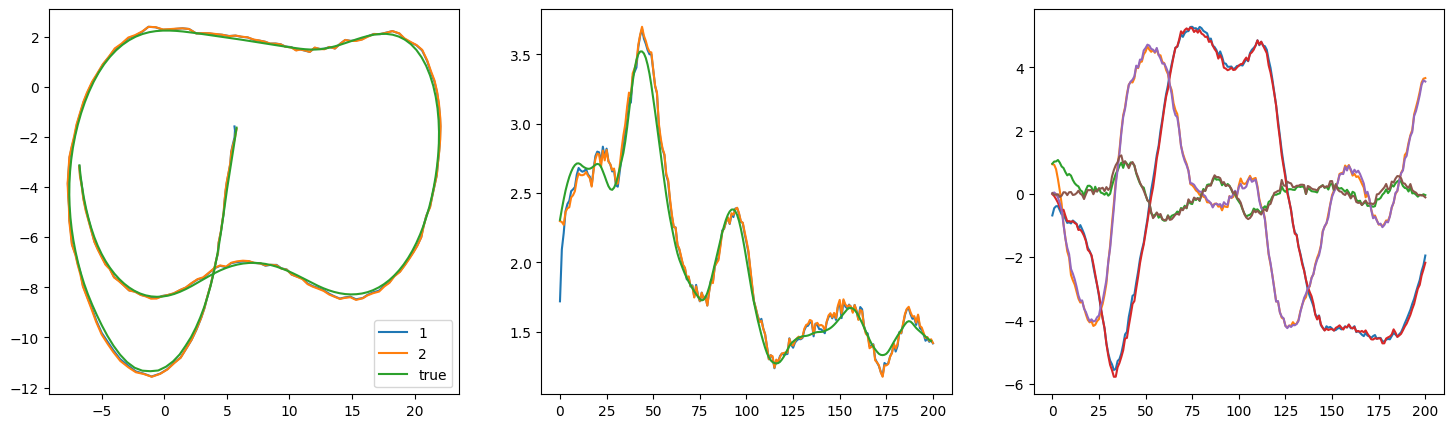

In [12]:
# means1 = np.array([p.mean for p in particle_hist])
means1 = np.array([s.mean for s in ekf_hist])
means2 = np.array([p.mean for p in particle2_hist])


fig = plt.figure(0, figsize=(18, 5))
axs = fig.subplots(1, 3).flatten()
axs[0].plot(means1[1:, 0], means1[1:, 1], label="1")
axs[0].plot(means2[1:, 0], means2[1:, 1], label="2")
axs[0].plot(target_pos[..., 0], target_pos[..., 1], label="true")
axs[0].legend()

axs[1].plot(means1[:, 2])
axs[1].plot(means2[:, 2])
axs[1].plot(target_pos[..., 2])

axs[2].plot(means1[:, 3:])
axs[2].plot(means2[:, 3:])


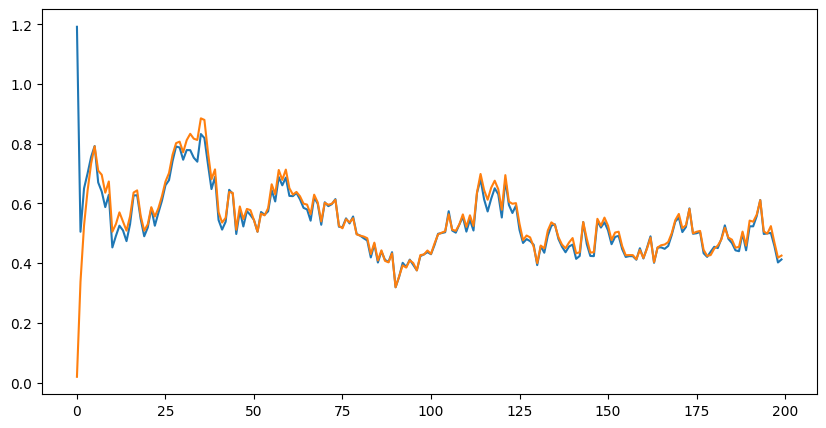

In [13]:
fig = plt.figure(1, figsize=(10, 5))
ax = fig.add_subplot()
ax.plot(jnp.linalg.norm(means1[:-1, :3] - target_pos, axis=-1))
ax.plot(jnp.linalg.norm(means2[:-1, :3] - target_pos, axis=-1))